
# **Attention Visualization Demo (Concepts from Transformer)**

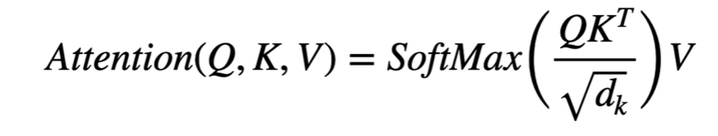

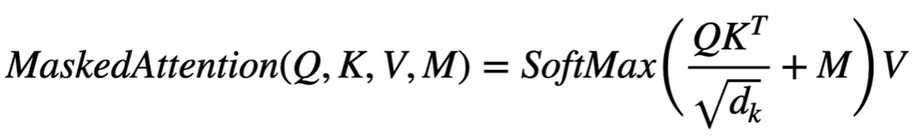

In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

torch.manual_seed(42)

# 1. Attention Module

In [27]:
class Attention(nn.Module):

    def __init__(self, d_model):
        super().__init__()

        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)

        # self.W_q = nn.Identity()
        # self.W_k = nn.Identity()
        # self.W_v = nn.Identity()


    def forward(self, enc_q, enc_k, enc_v, mask=None):

        Q = self.W_q(enc_q)
        K = self.W_k(enc_k)
        V = self.W_v(enc_v)

        # Compute similarity
        sims = torch.matmul(Q, K.T)

        # Scale
        scaled_sims = sims / torch.sqrt(torch.tensor(K.size(-1), dtype=torch.float32))

        # Apply mask if provided
        if mask is not None:
            scaled_sims = scaled_sims.masked_fill(mask, -1e9)

        # Softmax
        attn_weights = F.softmax(scaled_sims, dim=-1)

        # Weighted sum
        output = torch.matmul(attn_weights, V)

        return output, attn_weights


# 2. Multi-Head Attention

In [28]:
class MultiHeadAttention(nn.Module):

    def __init__(self, d_model, num_heads):
        super().__init__()

        self.heads = nn.ModuleList(
            [Attention(d_model) for _ in range(num_heads)]
        )

    def forward(self, enc_q, enc_k, enc_v):

        outputs = []
        weights = []

        for head in self.heads:
            out, attn = head(enc_q, enc_k, enc_v)
            outputs.append(out)
            weights.append(attn)

        # Concatenate outputs
        final_output = torch.cat(outputs, dim=-1)

        return final_output, weights


# 3. Visualization Utility

In [29]:
def visualize_attention(attn_matrix, query_tokens, key_tokens, title):

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        attn_matrix.detach().numpy(),
        xticklabels=key_tokens,
        yticklabels=query_tokens,
        cmap="viridis",
        annot=True,
        fmt=".2f"
    )
    plt.title(title)
    plt.xlabel("Key Words")
    plt.ylabel("Query Words")
    plt.show()

# 4. Example 1: Self-Attention


===== SELF-ATTENTION =====


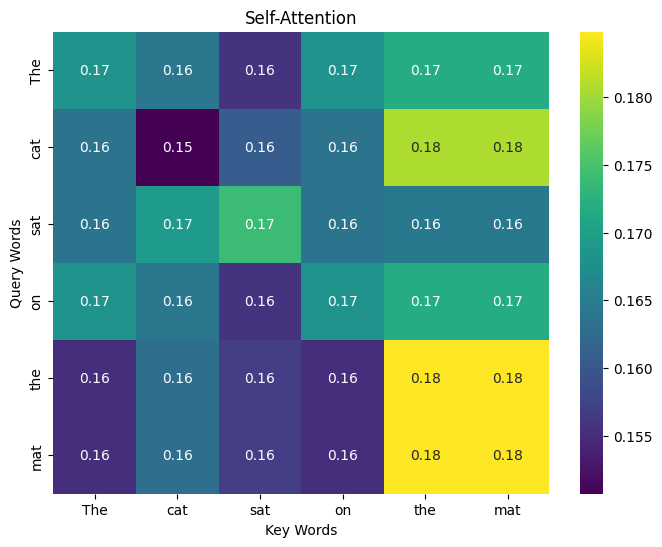

In [31]:
print("\n===== SELF-ATTENTION =====")

tokens = ["The", "cat", "sat", "on", "the", "mat"]
d_model = 4

#--------------------------------------------------------------

# Dummy embeddings (normally from embedding layer)
# embeddings = torch.randn(len(tokens), d_model)

#--------------------------------------------------------------
embeddings = torch.tensor([
    [0, 0, 0, 1],   # The  -> function word
    [1, 0, 0, 0],   # cat  -> animal
    [0, 1, 0, 0],   # sat  -> action
    [0, 0, 0, 1],   # on   -> function word
    [0, 0, 1, 0],   # the  -> object marker (pretend)
    [0, 0, 1, 0],   # mat  -> object
]).float()

#--------------------------------------------------------------

# embeddings = torch.tensor([
#     [0.0, 0.0, 0.0, 1.0],   # The (det)
#     [1.0, 0.0, 0.2, 0.0],   # cat (subject noun)
#     [0.8, 1.0, 0.3, 0.0],   # sat (verb influenced by subject & object)
#     [0.2, 0.4, 0.2, 1.0],   # on (relation word)
#     [0.0, 0.0, 0.0, 1.0],   # the
#     [0.3, 0.0, 1.0, 0.0],   # mat (object noun)
# ]).float()

#--------------------------------------------------------------

attention = Attention(d_model)

output, attn_weights = attention(embeddings, embeddings, embeddings)

visualize_attention(attn_weights, tokens, tokens, "Self-Attention")

# 5. Masked Self-Attention (Decoder Style)


===== MASKED SELF-ATTENTION =====


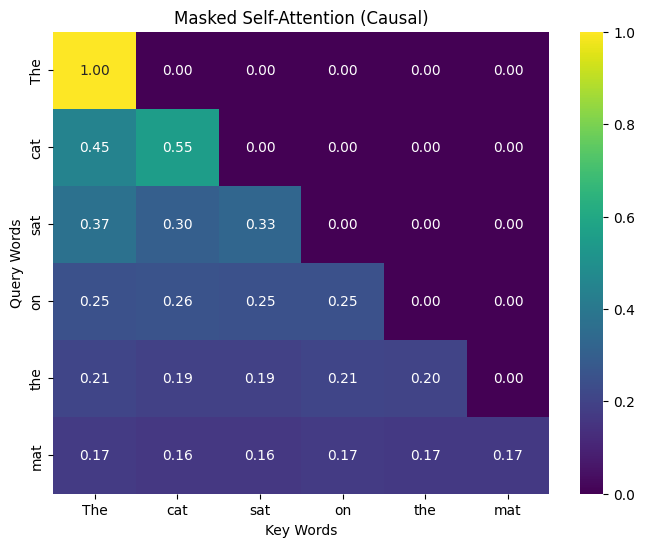

In [23]:
print("\n===== MASKED SELF-ATTENTION =====")

seq_len = len(tokens)

# Create causal mask (upper triangular)
mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1).bool()

output_masked, attn_masked = attention(embeddings, embeddings, embeddings, mask=mask)

visualize_attention(attn_masked, tokens, tokens, "Masked Self-Attention (Causal)")


# 6. Encoder-Decoder Attention


===== ENCODER-DECODER ATTENTION =====


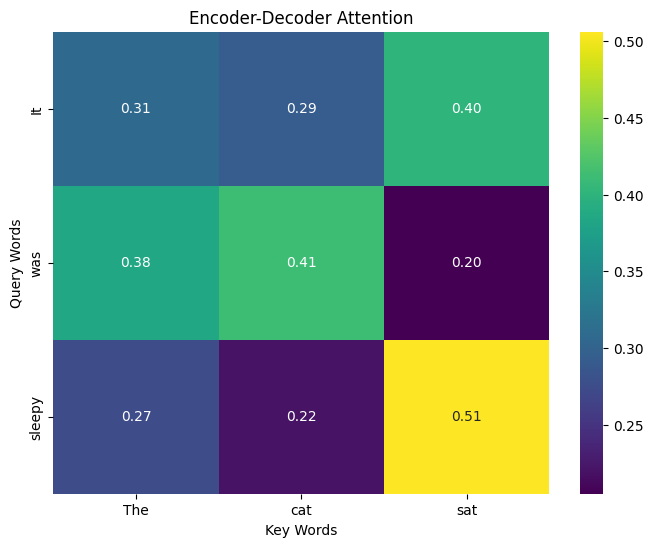

In [24]:
print("\n===== ENCODER-DECODER ATTENTION =====")

encoder_tokens = ["The", "cat", "sat"]
decoder_tokens = ["It", "was", "sleepy"]

encoder_embeddings = torch.randn(len(encoder_tokens), d_model)
decoder_embeddings = torch.randn(len(decoder_tokens), d_model)

output_cross, attn_cross = attention(
    decoder_embeddings,
    encoder_embeddings,
    encoder_embeddings
)

visualize_attention(
    attn_cross,
    decoder_tokens,
    encoder_tokens,
    "Encoder-Decoder Attention"
)

# 7. Multi-Head Attention


===== MULTI-HEAD ATTENTION =====


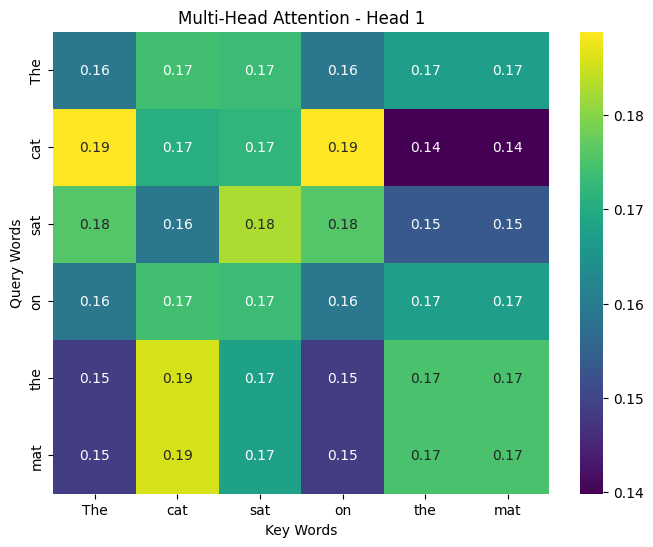

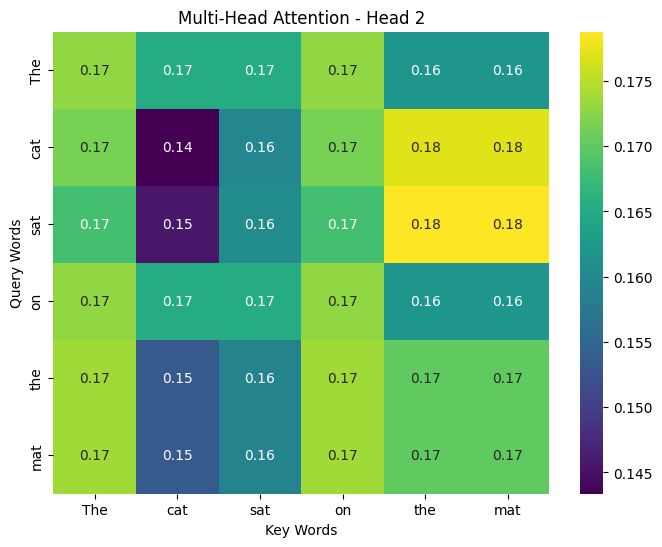

In [25]:
print("\n===== MULTI-HEAD ATTENTION =====")

num_heads = 2
multi_head = MultiHeadAttention(d_model, num_heads)

multi_output, multi_weights = multi_head(embeddings, embeddings, embeddings)

for i, head_weights in enumerate(multi_weights):
    visualize_attention(
        head_weights,
        tokens,
        tokens,
        f"Multi-Head Attention - Head {i+1}"
    )
